In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [46]:
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.001

TRAIN_DIR = "cifar3/train"
TEST_DIR = "cifar3/test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True

print("Устройство:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

Устройство: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA: 12.1


In [47]:
train_transform = transforms.Compose([

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [48]:
class MyCifarDataset(ImageFolder):

    def __init__(self, root, transform=None):

        super().__init__(
            root=root,
            transform=transform
        )

    def __getitem__(self, index):

        image, label = super().__getitem__(index)

        return image, label

In [49]:
train_dataset = MyCifarDataset(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset = MyCifarDataset(
    root=TEST_DIR,
    transform=test_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Классы:", train_dataset.classes)

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

Классы: ['apple', 'bus', 'dolphin']
Train images: 1500
Test images: 300


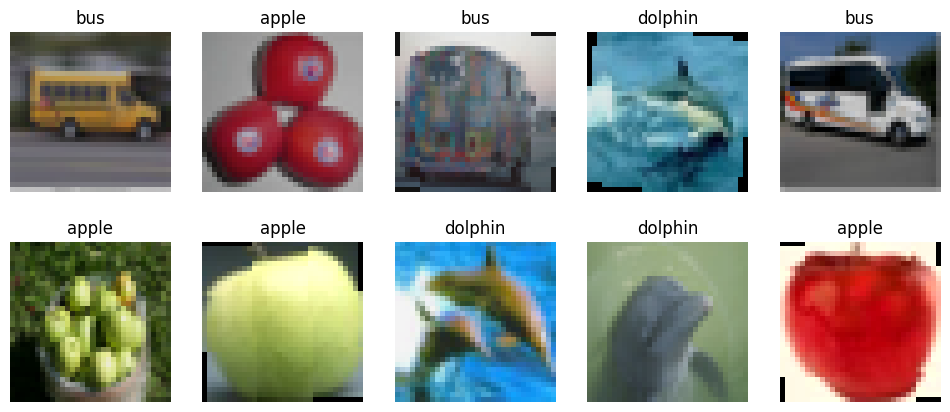

In [50]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):

    img = images[i]

    img = img / 2 + 0.5

    np_img = img.permute(1, 2, 0).numpy()

    ax.imshow(np_img)

    ax.set_title(train_dataset.classes[labels[i]])

    ax.axis("off")

plt.show()

In [51]:
class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(256, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 3)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [52]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.

In [53]:
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        loop.set_description(f"Epoch {epoch+1}/{EPOCHS}")

        loop.set_postfix(
            loss=loss.item(),
            accuracy=100 * correct / total
        )

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Loss = {epoch_loss:.4f}, "
        f"Accuracy = {epoch_accuracy:.2f}%"
    )

Epoch 1/20: 100%|██████████| 6/6 [00:00<00:00,  6.13it/s, accuracy=68.1, loss=0.453]


Epoch 1: Loss = 0.7108, Accuracy = 68.07%


Epoch 2/20: 100%|██████████| 6/6 [00:00<00:00,  6.14it/s, accuracy=86.1, loss=0.226]


Epoch 2: Loss = 0.3710, Accuracy = 86.13%


Epoch 3/20: 100%|██████████| 6/6 [00:00<00:00,  6.02it/s, accuracy=87.3, loss=0.384]


...

Epoch 18: Loss = 0.0526, Accuracy = 98.07%


Epoch 19/20: 100%|██████████| 6/6 [00:01<00:00,  4.55it/s, accuracy=97.9, loss=0.055] 


Epoch 19: Loss = 0.0573, Accuracy = 97.93%


Epoch 20/20: 100%|██████████| 6/6 [00:01<00:00,  4.61it/s, accuracy=98.5, loss=0.0662]

Epoch 20: Loss = 0.0486, Accuracy = 98.53%


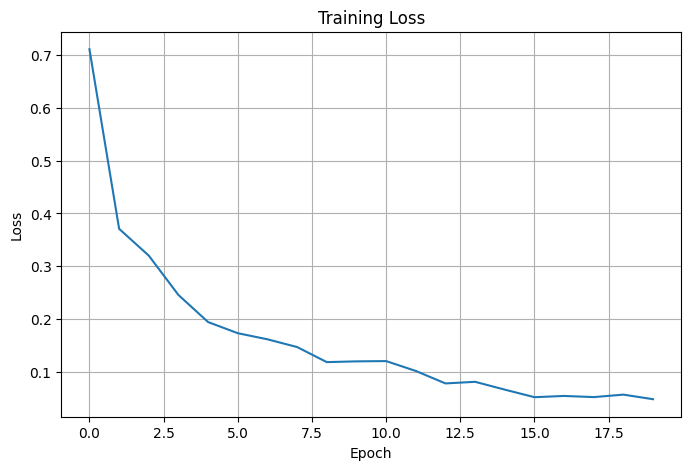

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

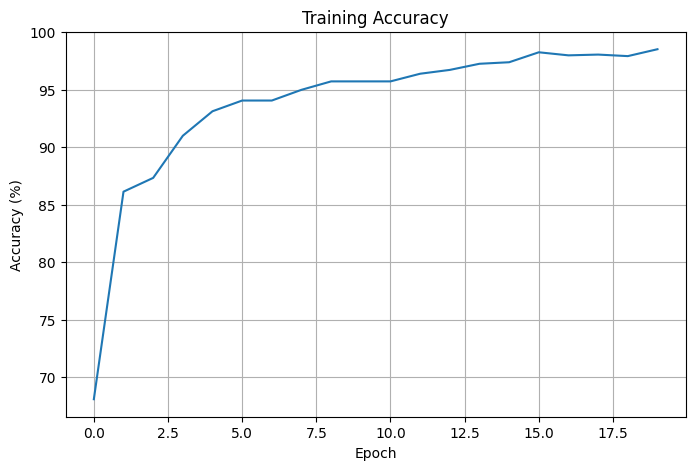

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid()

plt.show()

In [56]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 98.00%


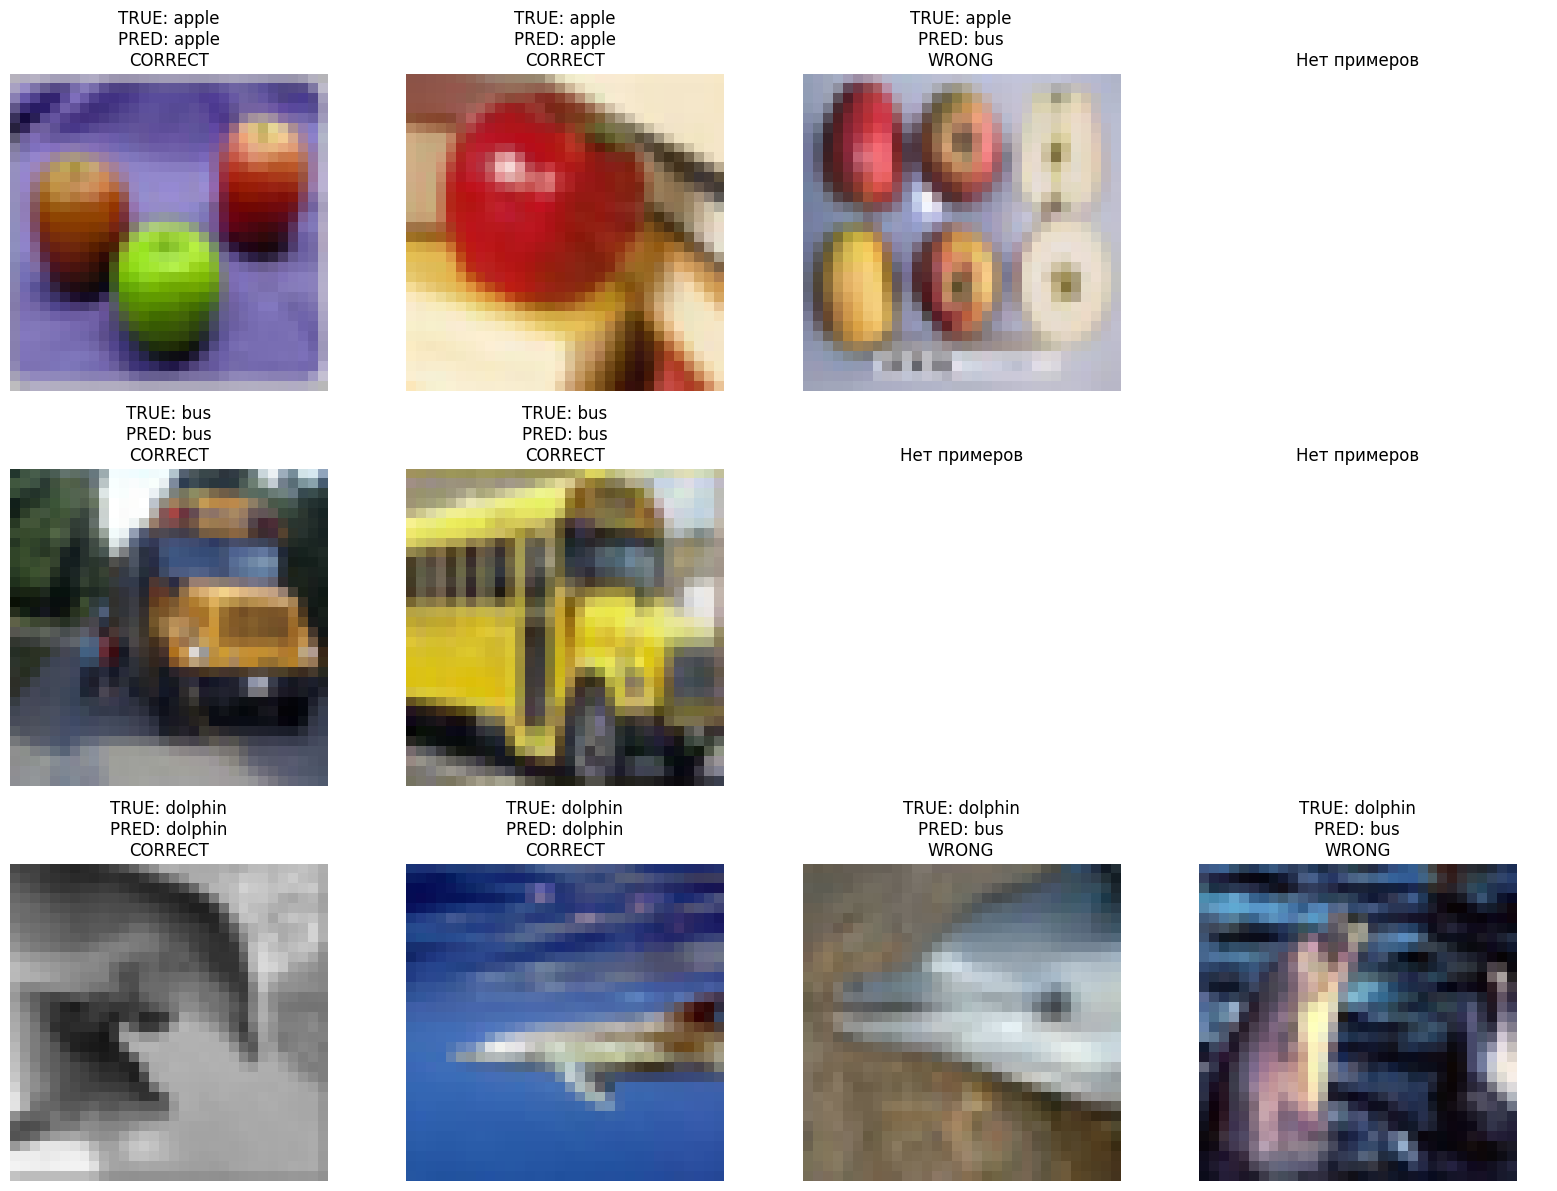

In [57]:
model.eval()

class_names = train_dataset.classes

results = {
    class_name: {
        "correct": [],
        "wrong": []
    }
    for class_name in class_names
}


with torch.no_grad():

    for images, labels in test_loader:

        images_gpu = images.to(device)

        outputs = model(images_gpu)

        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):

            true_idx = labels[i].item()

            pred_idx = predicted[i].item()

            true_class = class_names[true_idx]

            pred_class = class_names[pred_idx]

            image = images[i]

            if true_idx == pred_idx:

                if len(results[true_class]["correct"]) < 2:

                    results[true_class]["correct"].append(
                        (image, pred_class)
                    )

            else:

                if len(results[true_class]["wrong"]) < 2:

                    results[true_class]["wrong"].append(
                        (image, pred_class)
                    )


fig, axes = plt.subplots(3, 4, figsize=(16, 12))


for row, class_name in enumerate(class_names):

    examples = (
        results[class_name]["correct"] +
        results[class_name]["wrong"]
    )

    for col in range(4):

        ax = axes[row, col]

        if col < len(examples):

            img, pred_class = examples[col]

            img = img / 2 + 0.5

            np_img = img.permute(1, 2, 0).numpy()

            ax.imshow(np_img)

            is_correct = (
                pred_class == class_name
            )

            status = (
                "CORRECT"
                if is_correct
                else "WRONG"
            )

            ax.set_title(
                f"TRUE: {class_name}\n"
                f"PRED: {pred_class}\n"
                f"{status}"
            )

        else:

            ax.set_title("Нет примеров")

        ax.axis("off")


plt.tight_layout()

plt.show()